In [74]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

In [75]:
df =pd.read_csv('Hospital ER_Data (1).csv')

In [76]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [77]:
df.head(20)

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0
5,255-51-2877,20-04-2023 00:13,H,Buff,M,58,Asian,NaN,False,NaN,59,0
6,465-97-0990,23-08-2023 08:26,F,Perrat,F,68,White,NaN,True,NaN,43,0
7,157-31-7520,29-07-2023 16:57,K,Gwillim,F,47,Two or More Races,NaN,True,NaN,23,0
8,432-34-5614,19-02-2024 06:54,E,Dewhirst,F,79,White,NaN,False,1.0,42,0
9,609-17-8678,11-10-2024 05:25,M,Crebo,M,62,African American,NaN,False,NaN,51,0


In [78]:
df['Patient Satisfaction Score'] = df['Patient Satisfaction Score'].replace('No Feedback', np.nan)
df['Patient Satisfaction Score'] = df['Patient Satisfaction Score'].astype(float)

In [79]:
df['Department Referral'] = df['Department Referral'].fillna('No Referral')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         9216 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 801.1+ KB


In [96]:
df.duplicated().sum()

np.int64(0)

In [83]:

df['Patient Admission Date']=pd.to_datetime(df['Patient Admission Date'])
df['Day'] = df['Patient Admission Date'].dt.day
df['Month'] = df['Patient Admission Date'].dt.month
df['Year'] = df['Patient Admission Date'].dt.year 

C:\Users\91860\AppData\Local\Temp\ipykernel_19004\2440499703.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Patient Admission Date']=pd.to_datetime(df['Patient Admission Date'])


In [84]:
df['time'] = df['Patient Admission Date'].dt.time

In [87]:
df['time'] = pd.to_datetime(df['time'], format= '%H:%M:%S')

In [89]:
df['hour'] = df['time'].dt.hour

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Patient Id                  9216 non-null   object        
 1   Patient Admission Date      9216 non-null   datetime64[ns]
 2   Patient First Inital        9216 non-null   object        
 3   Patient Last Name           9216 non-null   object        
 4   Patient Gender              9216 non-null   object        
 5   Patient Age                 9216 non-null   int64         
 6   Patient Race                9216 non-null   object        
 7   Department Referral         9216 non-null   object        
 8   Patient Admission Flag      9216 non-null   bool          
 9   Patient Satisfaction Score  2517 non-null   float64       
 10  Patient Waittime            9216 non-null   int64         
 11  Patients CM                 9216 non-null   int64       

In [93]:
df.drop('Patient Admission Date', axis =1 , inplace=True)

In [99]:
df['Age_group'] = pd.cut(df['Patient Age'],
bins=[0,18,35,60,100],
labels=['Child','Young','Adult','Senior'])

In [101]:
df['hour'].value_counts().sort_index()

hour
0     406
1     372
2     376
3     385
4     384
5     393
6     375
7     415
8     386
9     388
10    349
11    403
12    366
13    410
14    368
15    394
16    378
17    359
18    370
19    383
20    372
21    376
22    372
23    436
Name: count, dtype: int64

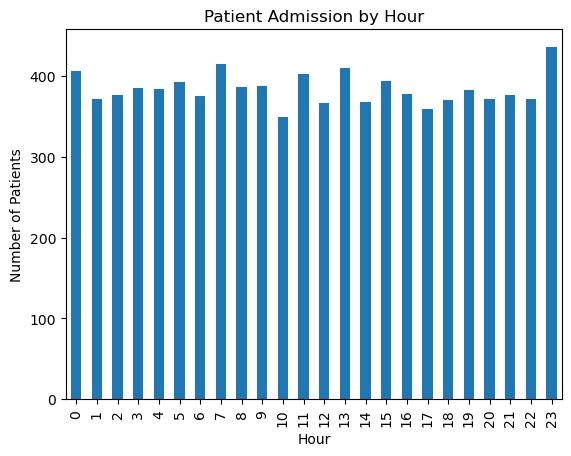

In [102]:
import matplotlib.pyplot as plt

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Patient Admission by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Patients")
plt.show()

In [106]:
df['Day'].value_counts().sort_values()

Day
31    160
6     257
13    268
26    284
7     285
4     288
30    288
14    288
2     293
19    295
9     296
27    298
5     299
11    302
24    302
20    302
23    303
10    304
18    308
28    309
17    312
29    312
15    313
25    313
22    314
8     314
16    315
3     316
21    319
12    323
1     336
Name: count, dtype: int64

In [110]:
df['Month'].value_counts().sort_index()

Month
1      513
2      431
3      506
4      948
5      999
6      991
7      952
8     1024
9      935
10     964
11     464
12     489
Name: count, dtype: int64

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Patient Id                  9216 non-null   object        
 1   Patient First Inital        9216 non-null   object        
 2   Patient Last Name           9216 non-null   object        
 3   Patient Gender              9216 non-null   object        
 4   Patient Age                 9216 non-null   int64         
 5   Patient Race                9216 non-null   object        
 6   Department Referral         9216 non-null   object        
 7   Patient Admission Flag      9216 non-null   bool          
 8   Patient Satisfaction Score  2517 non-null   float64       
 9   Patient Waittime            9216 non-null   int64         
 10  Patients CM                 9216 non-null   int64         
 11  Day                         9216 non-null   int32       

In [112]:
from sklearn.preprocessing import OneHotEncoder

In [113]:
encoder = OneHotEncoder()

In [114]:
encoder.fit_transform(df[['Patient Gender','Patient Race','Department Referral']]).toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(9216, 18))

In [118]:
encoded_data= pd.DataFrame(encoder.fit_transform(df[['Patient Gender','Patient Race','Department Referral']]).toarray(),columns=encoder.get_feature_names_out())

In [119]:
df_final = pd.concat([df,encoded_data],axis=1)

In [123]:
df_final.drop(['Patient Gender'],axis=1,inplace=True)

In [ ]:
df_final.drop(['Patient Race'],axis=1,inplace=True)

In [125]:
df_final.drop(['Department Referral'],axis=1,inplace=True)

In [ ]:
df_final.drop(['Patient Id'],axis=1,inplace=True)

In [130]:
df_final.drop(['Patient First Inital'],axis=1,inplace=True)

In [131]:
df_final.drop(['Patient Last Name'],axis=1,inplace=True)

In [132]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Patient Age                                 9216 non-null   int64         
 1   Patient Admission Flag                      9216 non-null   bool          
 2   Patient Satisfaction Score                  2517 non-null   float64       
 3   Patient Waittime                            9216 non-null   int64         
 4   Patients CM                                 9216 non-null   int64         
 5   Day                                         9216 non-null   int32         
 6   Month                                       9216 non-null   int32         
 7   Year                                        9216 non-null   int32         
 8   time                                        9216 non-null   datetime64[ns]
 9   hour    